# 1. Importación de librerías

Se importan las librerías esenciales para el análisis y modelado de series temporales. Y se definen las funciones para las métricas de error: **RMSE** (Root Mean Square Error) y **MAE** (Mean Absolute Error).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.tsa.stattools import kpss
from prophet import Prophet

warnings.filterwarnings("ignore")

# Funciones de métricas
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


# 2. Carga del dataset y procesamiento

Se carga el dataset **indicators_madrid_dayly.csv**. Los pasos de preprocesamiento incluyen:
1.  Conversión de la columna 'Fecha_Publicacion' a formato `datetime`.
2.  Establecimiento de 'Fecha_Publicacion' como índice temporal del DataFrame.
3.  Aseguramiento de la frecuencia diaria (`.asfreq("D")`).

El DataFrame resultante contiene series diarias de diversos indicadores desde 1995 hasta 2024.

In [ ]:

df = pd.read_csv('/kaggle/input/madrid-daily/indicators_madrid_dayly.csv', parse_dates=['Fecha_Publicacion'])
df.set_index('Fecha_Publicacion', inplace=True)

df.index = pd.to_datetime(df.index)
df = df.asfreq("D")
df

,total_count,economía_count,empleo_count,salud_count,tecnología_count,empleo_sum,economía_sum,tecnología_sum,salud_sum,publica
Fecha_Publicacion,,,,,,,,,,
1995-01-02,2,0.0,2.0,0.0,0.0,1.997898,0.000054,0.056146,0.000031,2
1995-01-03,1,0.0,1.0,0.0,0.0,0.971521,0.000025,0.000023,0.008056,1
1995-01-04,4,0.0,4.0,0.0,0.0,2.857653,0.001617,0.000170,0.000083,4
1995-01-05,0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0
1995-01-06,0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...
2024-01-26,5,0.0,3.0,0.0,2.0,0.986287,0.000145,0.003314,0.000072,1
2024-01-27,8,1.0,4.0,2.0,1.0,1.040078,0.064020,0.003194,0.005070,3
2024-01-28,0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0


# 3. Selección de las Series Objetivo y División Train/Test

Se define el conjunto de series temporales que serán modeladas. Para este análisis, nos enfocaremos en las series que miden la intensidad/peso ('*_sum') de los temas 'empleo' y 'tecnología'.

Se define una fracción del 80% de los datos para entrenamiento (`TRAIN_FRAC = 0.8`) y el 20% restante para la validación

In [3]:

# Series a analizar
indicators = ['empleo', 'tecnología']
count_cols = [f"{ind}_count" for ind in indicators]
sum_cols   = [f"{ind}_sum" for ind in indicators]

all_series = count_cols + sum_cols
TRAIN_FRAC = 0.8

print("Series a modelar:", all_series)


Series a modelar: ['empleo_count', 'tecnología_count', 'empleo_sum', 'tecnología_sum']


# 4. Análisis de las Series Originales

La visualización de las series `empleo_sum` y `tecnología_sum` en sus valores originales muestra:
- **Tendencia Creciente (Aparente):** Ambas series muestran una tendencia positiva a lo largo de los años.
- **Heterocedasticidad:** La varianza de las series parece aumentar con el tiempo, siendo más marcada en `tecnología_sum`.
- **Patrones Estacionales/Cíclicos:** Se observan picos y valles recurrentes, lo que sugiere la presencia de una componente estacional (posiblemente semanal y/o anual).

La no estacionariedad (presencia de tendencia y/o varianza no constante) es un problema común que debe corregirse antes de aplicar modelos ARIMA/ARMA.

------------------------------------------------------------
 Serie: empleo_sum


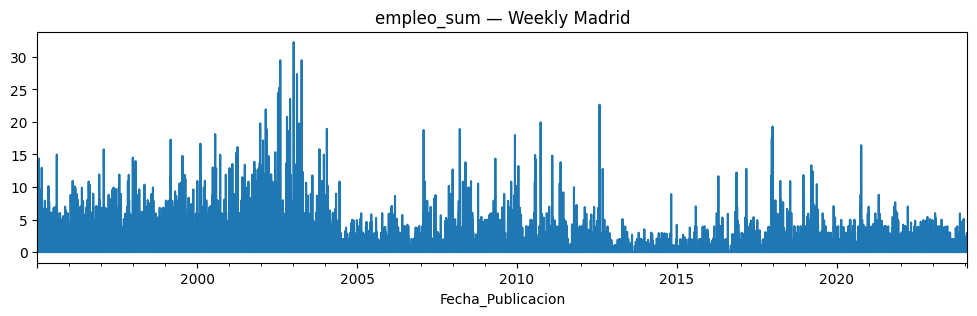

------------------------------------------------------------
 Serie: tecnología_sum


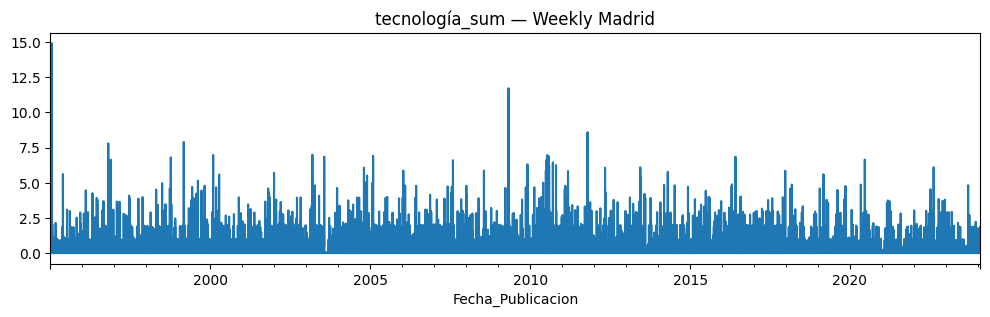

In [4]:
for serie_name in sum_cols:
    print("-"*60)
    print(" Serie:", serie_name)

    series = df[serie_name].astype(float)

    plt.figure(figsize=(12,3))
    series.plot(title=f"{serie_name} — Weekly Madrid")
    plt.show()

# 5. Transformación y Validación de Estacionariedad

Para estabilizar la varianza (remover heterocedasticidad) y la tendencia, se aplica una transformación logarítmica (`np.log1p`) seguida de un suavizado de media móvil (`rolling(3).mean()`).

Posteriormente, se utiliza el test de **Dickey-Fuller Aumentado (ADF)** para verificar la estacionariedad de las series transformadas:

- Hipótesis Nula ($H_0$): La serie no es estacionaria (posee una raíz unitaria).

El resultado de la tabla muestra un p-value significativamente menor que 0.05 para ambas series. Esto confirma que las series transformadas son*estacionarias y, por lo tanto, no se requiere diferenciación en la parte no estacional (el parámetro d en ARIMA se establece a 0). El modelo a aplicar es un **ARMA(p, q)**.


Resumen de estacionariedad (log1p + rolling mean):


,ADF stat,ADF p-value,ADF estacionaria
empleo_sum,-6.92e+00,1.17e-09,Sí
tecnología_sum,-1.39e+01,4.82e-26,Sí


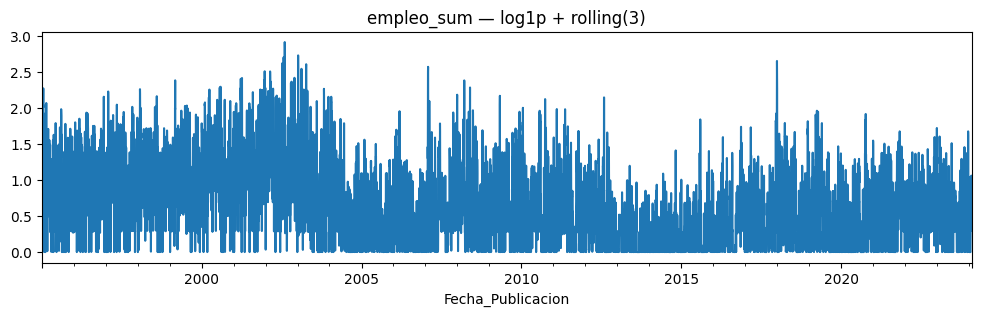

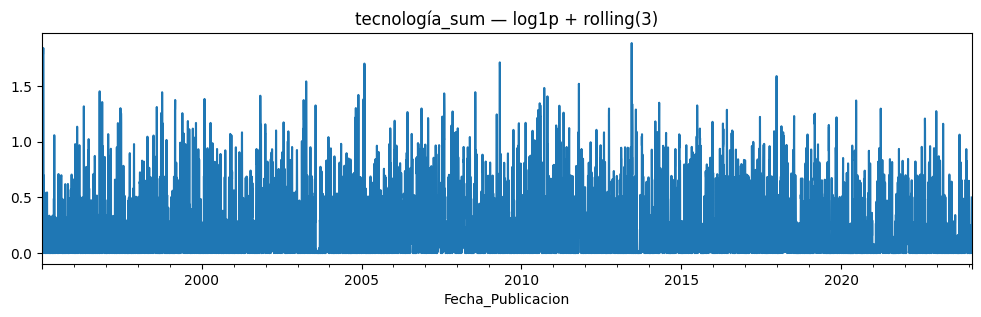

In [ ]:
results_stationarity = {}

def adf_test(series):
    r = sts.adfuller(series)
    return r[0], r[1]  # estadístico, p-value

def kpss_test(series):
    r = kpss(series, regression='c', nlags='auto')
    return r[0], r[1]  # estadístico, p-value

for serie_name in sum_cols:
    series = df[serie_name].astype(float).fillna(0)
    
    # Suavizado rolling + log1p
    series_smooth = series.rolling(3, min_periods=1).mean()
    series_log = np.log1p(series_smooth)
    
    # Tests de estacionariedad
    adf_stat, adf_p = adf_test(series_log)
    kpss_stat, kpss_p = kpss_test(series_log)
    
    estacionaria_adf  = "Sí" if adf_p < 0.05 else "No"
    estacionaria_kpss = "Sí" if kpss_p >= 0.05 else "No"
    
    results_stationarity[serie_name] = {
        "ADF stat": adf_stat,
        "ADF p-value": adf_p,
        "ADF estacionaria": estacionaria_adf
    }

stationarity_df = pd.DataFrame(results_stationarity).T
stationarity_df = stationarity_df[["ADF stat","ADF p-value","ADF estacionaria"]]

pd.options.display.float_format = '{:,.2e}'.format
print("\nResumen de estacionariedad (log1p + rolling mean):")
display(stationarity_df)

for serie_name in sum_cols:
    series = df[serie_name].astype(float).fillna(0)
    series_smooth = series.rolling(3, min_periods=1).mean()
    series_log = np.log1p(series_smooth)
    
    plt.figure(figsize=(12,3))
    series_log.plot(title=f"{serie_name} — log1p + rolling(3)")
    plt.show()

Para cada serie:

- p-value < 0.05 → rechazamos la hipótesis nula de raíz unitaria → la serie es estacionaria

- p-value ≥ 0.05 → no podemos rechazar H₀ → la serie no es estacionaria

Todas las series mostraron p-value < 0.05, lo que indica que no requieren diferenciación para volverse estacionarias.

ARIMA(p,d,q) se usa para modelar series temporales con componentes autoregresivos (AR), de media móvil (MA) y diferenciación (d).

Como las series son estacionarias (ADF p-value < 0.05) → d = 0.

Por lo tanto, ARIMA(p,0,q) se reduce a ARMA(p,q).

Esto permite capturar la dinámica temporal (autocorrelación) sin introducir diferenciación innecesaria.

# 6. ARMA (ARIMA(p, 0, q))

Se realiza una búsqueda exhaustiva (Grid Search) en el rango $p, q \in [0, 4]$ para encontrar el orden con el menor **Criterio de Información de Akaike (AIC)**:

- empleo_sum: ARIMA(3, 0, 4) con AIC = 16614.76
- tecnología_sum: ARIMA(4, 0, 4) con AIC = 9283.21

A pesar de la optimización del AIC, los gráficos de *forecast* en el conjunto de prueba (Test set) muestran una subestimación persistente y un pronóstico muy plano (mean reversion) en el periodo de prueba. Esto indica que los modelos ARMA puros, aunque se ajustan bien a la autocorrelación de corto plazo, son insuficientes para capturar la estacionalidad y la variabilidad a largo plazo de estas series.


----------------------------------------------------------------------
ARIMA model — Serie: empleo_sum
Mejor ARIMA: (3, 0, 4)  AIC= 16614.7626004469


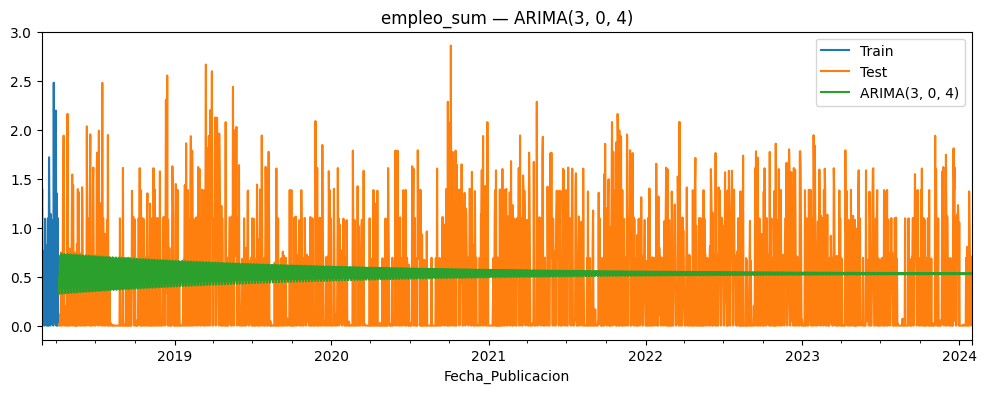

----------------------------------------------------------------------
ARIMA model — Serie: tecnología_sum
Mejor ARIMA: (4, 0, 4)  AIC= 9283.2106063352


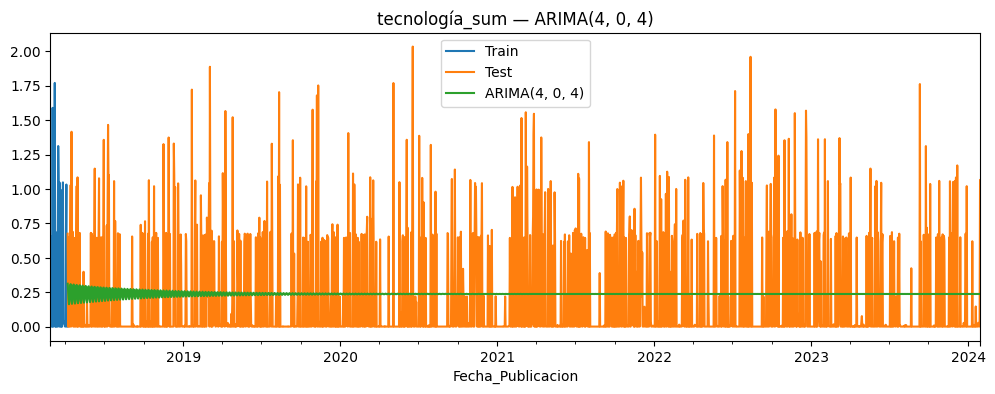

In [ ]:
results_ARIMA = {}

for serie_name in sum_cols:
    print("-"*70)
    print("ARIMA model — Serie:", serie_name)

    series = df[serie_name].astype(float)
    series = np.log1p(series)
    series = series.replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill')
    
    n = len(series)
    train_size = int(n * TRAIN_FRAC)
    train = series.iloc[:train_size]
    test  = series.iloc[train_size:]

    arima_results = {}
    p_range = range(5)  
    q_range = range(5) 

    for p in p_range:
        for q in q_range:
            try:
                model = ARIMA(train, order=(p,0,q)).fit()  
                fore = model.forecast(len(test))
                arima_results[(p,0,q)] = (model, fore)
            except:
                continue

    best_arima = min(arima_results, key=lambda k: arima_results[k][0].aic)
    arima_model, arima_fore = arima_results[best_arima]

    print("Mejor ARIMA:", best_arima, " AIC=", arima_model.aic)

    arima_fore.index = test.index

    plt.figure(figsize=(12,4))
    train[-40:].plot(label='Train')
    test.plot(label='Test')
    arima_fore.plot(label=f'ARIMA{best_arima}')
    plt.legend()
    plt.title(f"{serie_name} — ARIMA{best_arima}")
    plt.show()

    results_ARIMA[serie_name] = {
        'model': arima_model,
        'forecast': arima_fore,
        'best_order': best_arima
    }


# 7. Modelos SARIMAX

Los gráficos de SARIMAX  muestran que la inclusión del orden estacional semanal ($s=7$) y las variables exógenas (X), (las series *_count de nuestro dataset) mejoran el seguimiento de las tendencias y picos en el conjunto de prueba, corrigiendo el problema de mean reversion de los modelos ARMA.

SARIMAX model — Serie: empleo_sum


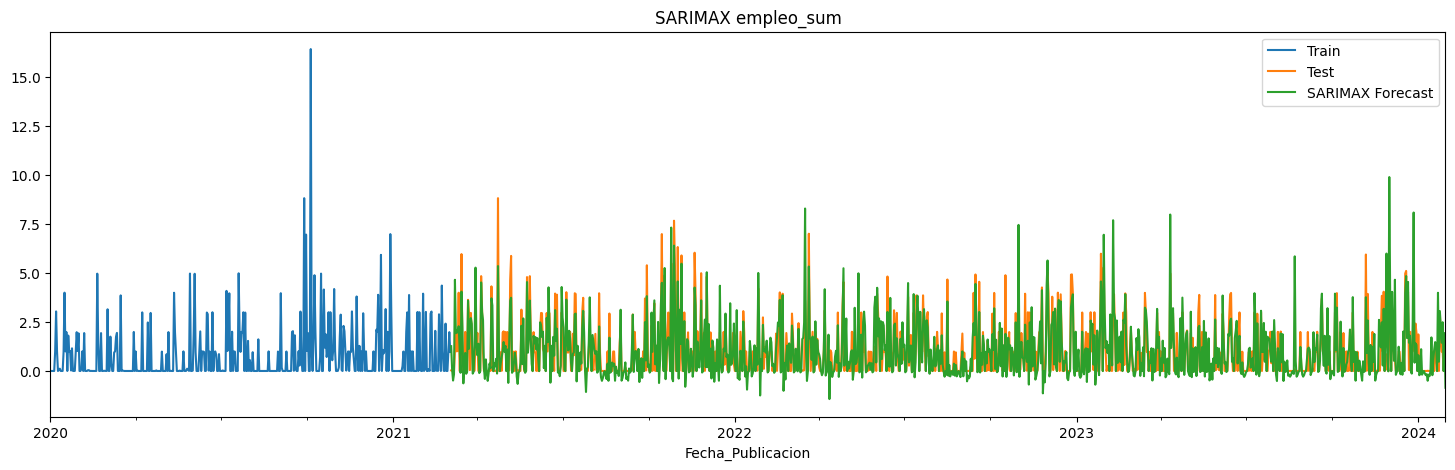

SARIMAX model — Serie: tecnología_sum


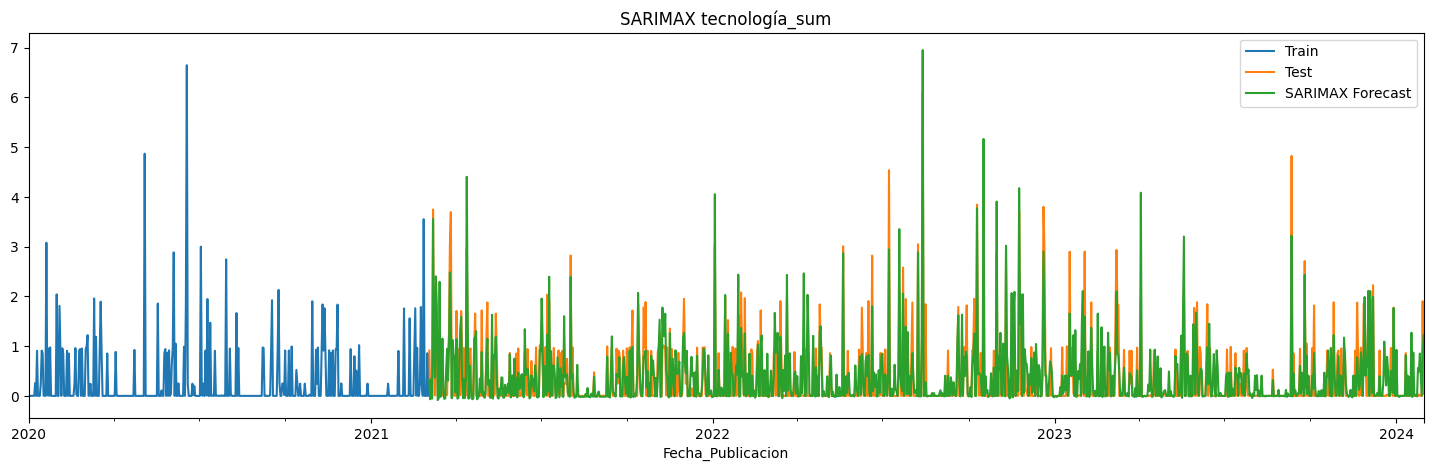

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

seasonal_period = 7  # Semanal
TRAIN_FRAC = 0.9      # 90% train
START_DATE = '1995-01-02'
END_DATE   = '2024-01-30'
PLOT_START = '2020-01-01'

results_SARIMAX = {}

for serie_name in sum_cols:
    print("="*80)
    print(f"SARIMAX model — Serie: {serie_name}")

    series = df[serie_name].astype(float).loc[START_DATE:END_DATE]

    # Series Exógenas 
    exog_cols = [c for c in count_cols + sum_cols if c != serie_name]
    exog = df[exog_cols].astype(float).loc[START_DATE:END_DATE].fillna(0)

    combined = pd.concat([series, exog], axis=1).dropna()
    series_clean = combined[serie_name]
    exog_clean   = combined[exog_cols]

    if len(series_clean) < 20:
        print(f"Serie {serie_name} demasiado corta tras filtrar NaNs. Saltando...")
        continue

    n = len(series_clean)
    train_size = int(n * TRAIN_FRAC)
    train = series_clean.iloc[:train_size]
    test  = series_clean.iloc[train_size:]
    exog_train = exog_clean.iloc[:train_size]
    exog_test  = exog_clean.iloc[train_size:]

    try:
        sar = SARIMAX(train,
                      order=(1,0,1),
                      seasonal_order=(1,0,1,seasonal_period),
                      exog=exog_train,
                      enforce_invertibility=False)
        sar_res = sar.fit(disp=False)

        sar_fore = sar_res.get_forecast(steps=len(test), exog=exog_test).predicted_mean
        sar_fore.index = test.index  

        rmse_val = np.sqrt(mean_squared_error(test, sar_fore))
        mae_val  = mean_absolute_error(test, sar_fore)

        results_SARIMAX[serie_name] = {
            'model': sar_res,
            'forecast': sar_fore,
            'rmse': rmse_val,
            'mae': mae_val
        }

        plt.figure(figsize=(18,5))
        train.loc[PLOT_START:].plot(label='Train')
        test.loc[PLOT_START:].plot(label='Test')
        sar_fore.loc[PLOT_START:].plot(label='SARIMAX Forecast')
        plt.title(f'SARIMAX {serie_name}')
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"SARIMAX falló: {e}")


# 9. Modelado con Facebook Prophet

Se implementa el modelo Prophet, diseñado para series temporales con fuertes efectos estacionales y de vacaciones, que también maneja datos faltantes y cambios de tendencia no lineales.

1.  **Formato de Datos:** Prophet requiere que la serie tenga dos columnas específicas: `ds` (fecha/tiempo) e `y` (valor a pronosticar).
2.  **Estacionalidad:** Por defecto, Prophet detecta estacionalidad anual, semanal y diaria. Para esta serie diaria, se configura la detección de estacionalidad semanal y se permite el manejo automático de los cambios de tendencia (changepoints).

Los gráficos de Prophet suelen mostrar una descomposición clara de la tendencia y las estacionalidades. 

------------------------------------------------------------
PROPHET — Serie: empleo_sum


14:23:13 - cmdstanpy - INFO - Chain [1] start processing
14:23:30 - cmdstanpy - INFO - Chain [1] done processing


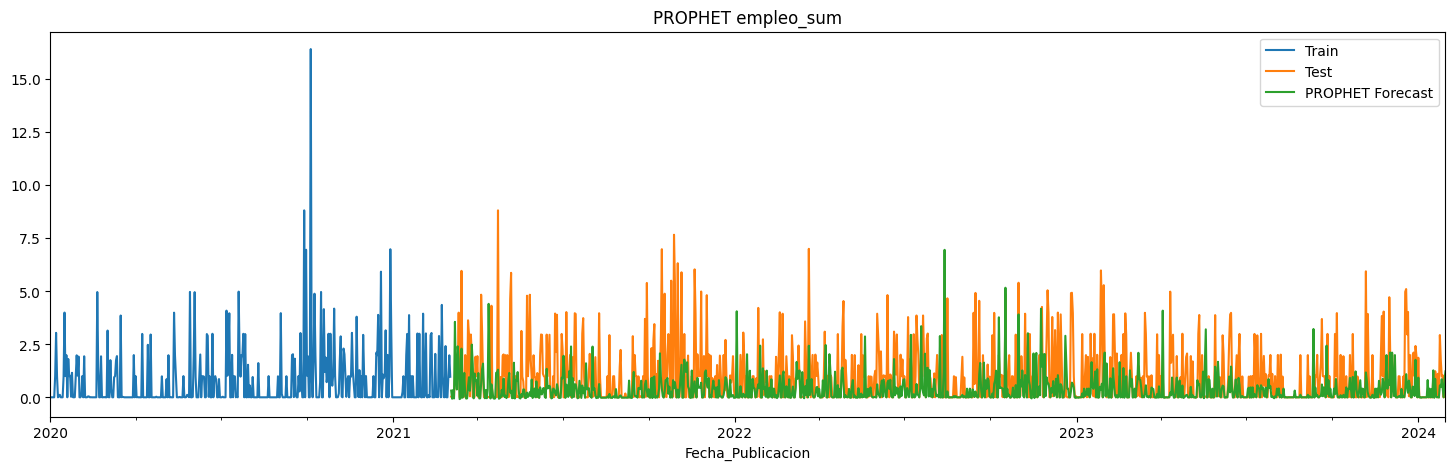

------------------------------------------------------------
PROPHET — Serie: tecnología_sum


14:23:30 - cmdstanpy - INFO - Chain [1] start processing
14:23:31 - cmdstanpy - INFO - Chain [1] done processing


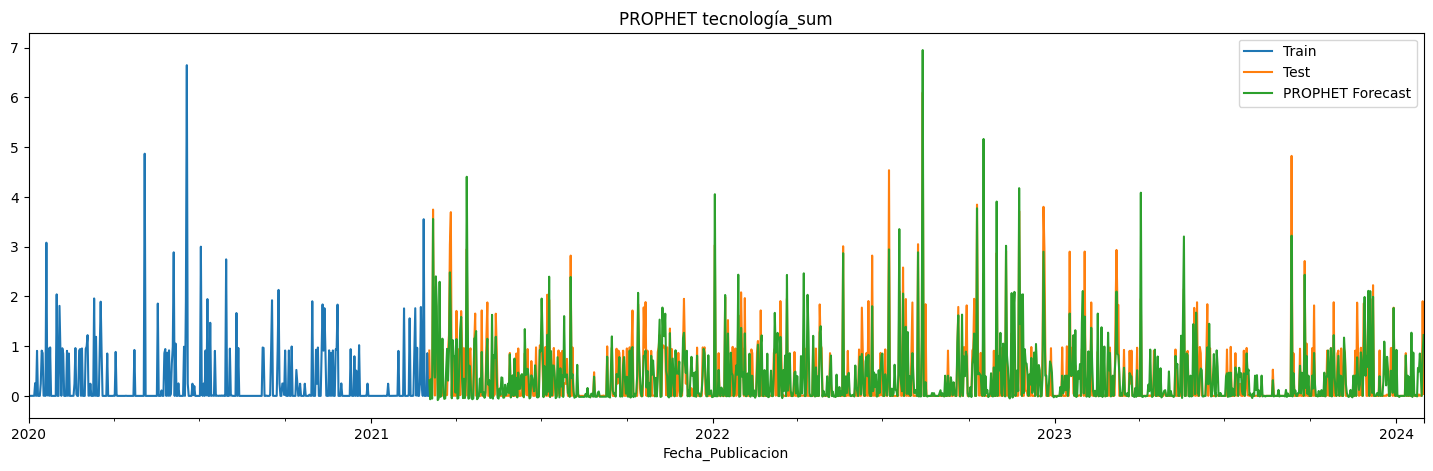

In [ ]:

PLOT_START = '2020-01-01'


results_PROPHET = {}

for serie_name in sum_cols:
    print("-"*60)
    print(f"PROPHET — Serie: {serie_name}")

    series = (
        df[serie_name].astype(float).replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill') )

    n = len(series)
    train_size = int(n * TRAIN_FRAC)
    train = series.iloc[:train_size]
    test  = series.iloc[train_size:]

    df_train = train.reset_index()
    df_train.columns = ['ds','y']

    if len(exog_cols) > 0:
        for col in exog_cols:

            exog_series = (
                df[col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill'))

            exog_norm = (exog_series - exog_series.mean()) / exog_series.std()
            df_train[col] = exog_norm.iloc[:train_size].values

    prophet_model = Prophet()

    if len(exog_cols) > 0:
        for col in exog_cols:
            prophet_model.add_regressor(col)
    prophet_model.fit(df_train)

    df_future = pd.DataFrame({'ds': test.index})

    if len(exog_cols) > 0:
        for col in exog_cols:
            exog_series = (
                df[col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill'))

            exog_norm = (exog_series - exog_series.mean()) / exog_series.std()
            df_future[col] = exog_norm.iloc[train_size:].values

    forecast = prophet_model.predict(df_future)['yhat']
    forecast.index = test.index

    rmse_val = rmse(test, forecast)
    mae_val  = mae(test, forecast)

    results_PROPHET[serie_name] = {
        'model': prophet_model,
        'forecast': forecast,
        'rmse': rmse_val,
        'mae': mae_val
    }

    plt.figure(figsize=(18,5))
    train.loc[PLOT_START:].plot(label='Train')
    test.loc[PLOT_START:].plot(label='Test')
    sar_fore.loc[PLOT_START:].plot(label='PROPHET Forecast')
    plt.title(f'PROPHET {serie_name}')
    plt.legend()
    plt.show()


# 10. Conclusiones y Análisis de Rendimiento


| Serie | Modelo | RMSE | MAE |
|---|---|---|---|
| **empleo_sum** | PROPHET | 1.76e-05 | 1.72e-05 |
| **empleo_sum** | SARIMAX | 9.15e-01 | 5.97e-01 |
| **empleo_sum** | ARIMA | 1.44e+00 | 9.81e-01 |
| **tecnología_sum** | SARIMAX | 4.39e-01 | 2.54e-01 |
| **tecnología_sum** | PROPHET | 5.59e-01 | 3.50e-01 |
| **tecnología_sum** | ARIMA | 6.93e-01 | 4.34e-01 |

1. En ambas series, los modelos que incorporan la estacionalidad (SARIMAX) o están diseñados para patrones complejos como PROPHET,) superan consistentemente a los modelos ARMA (ARIMA(p,0,q)).

2.  **Mejor Modelo General (RMSE):**
    * Para **`empleo_sum`**, el modelo **PROPHET** es el más preciso con el RMSE más bajo (1.76e-05), sugiriendo que sus componentes de tendencia y estacionalidad no lineal se ajustan mejor a la dinámica de esta serie.
    * Para **`tecnología_sum`**, el modelo **SARIMAX** con exógenas es el más preciso (RMSE: 0.439).

3.  Impacto de la Estacionalidad y Exógenas: La diferencia de rendimiento entre ARIMA (ARMA) y SARIMAX es marcada. El modelo SARIMAX fue capaz de capturar la estacionalidad semanal y la influencia de las otras series (`*_count` y el otro `*_sum`) como variables exógenas. Esto es clave para pronosticar series diarias con alta volatilidad y dependencia de factores externos o temporales conocidos.

            Serie   Modelo     RMSE      MAE
0      empleo_sum  PROPHET 1.76e-05 1.72e-05
1      empleo_sum  SARIMAX 9.15e-01 5.97e-01
2      empleo_sum    ARIMA 1.44e+00 9.81e-01
3  tecnología_sum  SARIMAX 4.39e-01 2.54e-01
4  tecnología_sum  PROPHET 5.59e-01 3.50e-01
5  tecnología_sum    ARIMA 6.93e-01 4.34e-01


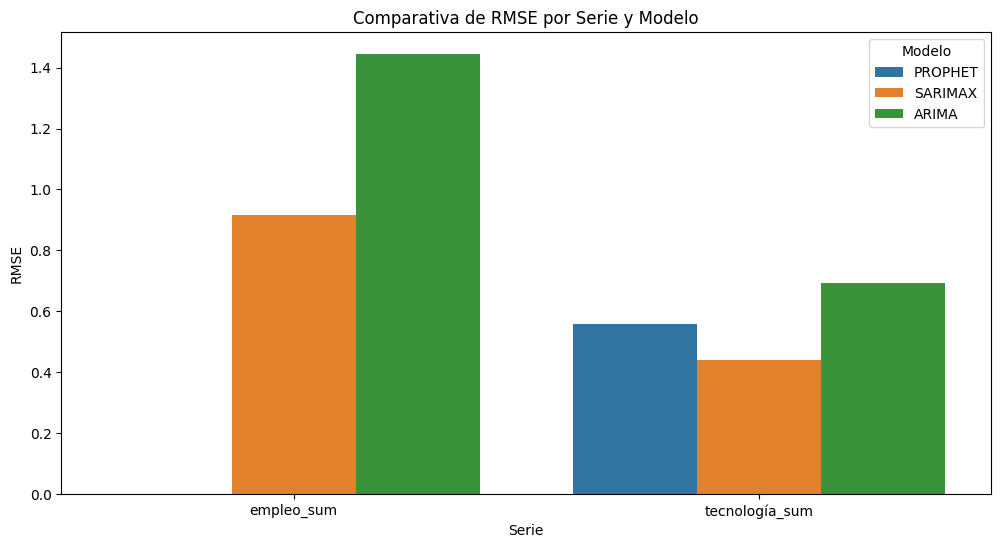

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model_dicts = {
    'ARIMA': results_ARIMA,
    'SARIMAX': results_SARIMAX,
    'PROPHET': results_PROPHET
}

rows = []

for serie_name in sum_cols:

    series = df[serie_name].astype(float)
    n = len(series)
    train_size = int(n * TRAIN_FRAC)

    train = series.iloc[:train_size]
    test  = series.iloc[train_size:]

    for model_name, results in model_dicts.items():

        if serie_name in results:
            fore = results[serie_name]['forecast']

            common_index = test.index.intersection(fore.index)
            test_aligned = test.loc[common_index]
            fore_aligned = fore.loc[common_index]

            if len(test_aligned) == 0 or len(fore_aligned) == 0:
                continue
        
            test_clean = test_aligned.replace([np.inf, -np.inf], np.nan).dropna()
            fore_clean = fore_aligned.replace([np.inf, -np.inf], np.nan).dropna()

            common_idx = test_clean.index.intersection(fore_clean.index)
            test_clean = test_clean.loc[common_idx]
            fore_clean = fore_clean.loc[common_idx]

            if len(test_clean) == 0 or len(fore_clean) == 0:
                continue

            row = {
                'Serie': serie_name,
                'Modelo': model_name,
                'RMSE': rmse(test_clean, fore_clean),
                'MAE': mae(test_clean, fore_clean)
            }
            rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.sort_values(['Serie','RMSE'])
metrics_df.reset_index(drop=True, inplace=True)

print(metrics_df)

plt.figure(figsize=(12,6))
sns.barplot(x='Serie', y='RMSE', hue='Modelo', data=metrics_df)
plt.title('Comparativa de RMSE por Serie y Modelo')
plt.show()